<a href="https://colab.research.google.com/github/kallestrous1/Deep-Learning-Telemetry-Anomaly-Detection/blob/main/Comp432MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Overview

Goal: train a model to identify anomalous gameplay sessions based on telemtry data I collect from my own game.

I import data from two different sources (a difficult database migration happened:), which provides a few challenges. Events are uploaded from sqlite and postgres tables, and merged. These events are then tokenized and turned into session vectors.

I train two sequence models (baseline and GRU) to predict the next event in a session, and learn the patterns of normal gameplay behavior. Anomalies are identified by measuring how unlikely observed events are under the trained model, allowing sessions with unusual behavior to be flagged.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
pip install "black[jupyter]"

In [61]:
!black .

All done! ✨ 🍰 ✨
1 file left unchanged.


# Get events

To reproduce the results please upload the attached datasets to your drive and modify the file_paths in the two cells below.

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Huiswerk/Comp 432/sqliteevents.csv"
sqliteRawEvents = pd.read_csv(file_path)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print(sqliteRawEvents.head())

   id eventType         eventData   timestamp                              playerId                             sessionId              runId payload
0   1   Session     session_start  1767819484  cbcdb62f-df0a-44e0-891a-2fdce0144b71  16cb9f78-d705-4bdb-b871-9e32ef2713c9  DEV_PLAYER_EDITOR     NaN
1   2   Session     session_start  1767819485                     DEV_PLAYER_EDITOR  62514a76-fac0-40f8-a766-9fb88c101a40  DEV_PLAYER_EDITOR     NaN
2   3   Session     session_start  1767819492                     DEV_PLAYER_EDITOR  cef8a786-a8d1-4abf-8e28-8b7cdff473ca  DEV_PLAYER_EDITOR     NaN
3   4   Session     session_start  1767819494                     DEV_PLAYER_EDITOR  25cf175f-f206-4976-b1ed-521633e592c0  DEV_PLAYER_EDITOR     NaN
4   5   Session  new_game_started  1767819494                     DEV_PLAYER_EDITOR  25cf175f-f206-4976-b1ed-521633e592c0  DEV_PLAYER_EDITOR     NaN


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/Huiswerk/Comp 432/events_firsttest.csv"
postgrepSQLRawEvents = pd.read_csv(file_path)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print(postgrepSQLRawEvents.head())

     id     event_type                                         event_data  timestamp_ms          player_id                            session_id             run_id                                            payload                    received_at
0  3364        Session                                        session_end    1772410621  DEV_PLAYER_EDITOR  cf9e6ac5-f73a-4696-b726-78de10425ed7  DEV_PLAYER_EDITOR                      {"cause": "application_quit"}  2026-03-01 19:17:01.113 -0500
1  3363  PlayerDamaged  Player took damage. Scene:_BanditCampEntrance,...    1772410619  DEV_PLAYER_EDITOR  cf9e6ac5-f73a-4696-b726-78de10425ed7  DEV_PLAYER_EDITOR  {"source": "shockwave(Clone)", "sceneName": "B...  2026-03-01 19:17:00.817 -0500
2  3362  PlayerDamaged  Player took damage. Scene:_BanditCampEntrance,...    1772410616  DEV_PLAYER_EDITOR  cf9e6ac5-f73a-4696-b726-78de10425ed7  DEV_PLAYER_EDITOR  {"source": "shockwave(Clone)", "sceneName": "B...  2026-03-01 19:17:00.817 -0500
3  3361      Bos

#Helper Functions
Due to the different tables and formats that need to be normalized, a few helper functions are necessary to simplify the process later on.

In [ ]:
import json
import re


def clean_string(x):
    """
    Normalize and clean a string value for consistent tokenization.

    This function converts input values to lowercase strings, removes
    specific substrings (e.g., "(clone)", "(fireball)"), strips trailing
    digits, removes whitespace, and ensures a non-empty output.

    Parameters
    ----------
    x : Any
        Input value to be cleaned. Can be a string, number, or NaN.

    Returns
    -------
    str
        Cleaned string representation. Returns "none" if input is missing
        or results in an empty string.
    """
    if pd.isna(x):
        return "none"
    x = str(x).lower().strip()
    x = x.replace("(clone)", "")
    x = x.replace("(fireball)", "")
    x = re.sub(r"\d+$", "", x)  # mosquito1 -> mosquito
    x = x.replace(" ", "")
    return x if x else "none"


def get_clean(row, col):
    """
    Safely extract and clean a value from a row-like object.

    Parameters
    ----------
    row : dict-like or pandas.Series
        Row containing event data.
    col : str
        Column name to extract.

    Returns
    -------
    str
        Cleaned string value from the specified column, or "none"
        if the column is missing or contains invalid data.
    """
    if col not in row:
        return "none"
    return clean_string(row[col])


def extract_actor(row):
    """
    Extract the primary actor associated with an event.

    The function prioritizes different fields in order of relevance:
    source → enemyType → itemType → cause.

    Parameters
    ----------
    row : dict-like or pandas.Series
        Row containing event data.

    Returns
    -------
    str
        Cleaned actor identifier, or "none" if no valid actor is found.
    """
    if "source" in row and pd.notna(row["source"]):
        return clean_string(row["source"])
    if "enemyType" in row and pd.notna(row["enemyType"]):
        return clean_string(row["enemyType"])
    if "itemType" in row and pd.notna(row["itemType"]):
        return clean_string(row["itemType"])
    if "cause" in row and pd.notna(row["cause"]):
        return clean_string(row["cause"])
    return "none"


def extract_item_action(event_data):
    """
    Parse item equip/unequip actions from event data.

    Recognizes strings of the form "equipping:<item>" or
    "unequipping:<item>" and converts them into standardized tokens.

    Parameters
    ----------
    event_data : Any
        Raw event data field, typically a string.

    Returns
    -------
    str
        Token representing the action (e.g., "equip_sword",
        "unequip_shield"), or "none" if no valid action is found.
    """
    if pd.isna(event_data):
        return "none"

    s = str(event_data).strip().lower()

    if s.startswith("equipping:"):
        item = s.split(":", 1)[1].strip()
        item = clean_string(item)
        return f"equip_{item}" if item != "none" else "none"

    if s.startswith("unequipping:"):
        item = s.split(":", 1)[1].strip()
        item = clean_string(item)
        return f"unequip_{item}" if item != "none" else "none"

    return "none"

    return "none"


def parse_payload(payload):
    """
    Parse a payload field into a dictionary.

    Handles multiple formats including:
    - JSON strings
    - Python literal strings
    - byte-encoded data

    Attempts repeated decoding to handle nested or stringified payloads.

    Parameters
    ----------
    payload : Any
        Raw payload data (string, dict, bytes, or NaN).

    Returns
    -------
    dict
        Parsed dictionary representation of the payload.
        Returns an empty dict if parsing fails.
    """
    # missing values
    if pd.isna(payload):
        return {}

    obj = payload

    # handle bytes
    if isinstance(obj, bytes):
        try:
            obj = obj.decode("utf-8")
        except Exception:
            return {}

    # try repeated decoding a few times
    for _ in range(4):
        if isinstance(obj, dict):
            return obj

        if not isinstance(obj, str):
            return {}

        obj = obj.strip()

        if obj == "" or obj == "{}" or obj.lower() == "nan":
            return {}

        # first try normal JSON
        try:
            obj = json.loads(obj)
            continue
        except Exception:
            pass

        # then try Python-literal style dict strings
        try:
            obj = ast.literal_eval(obj)
            continue
        except Exception:
            return {}

    return obj if isinstance(obj, dict) else {}


def extract_context(row, event_col, data_col):
    """
    Extract contextual information for an event.

    This function derives a context string based on event type and
    associated fields (e.g., scene transitions, damage sources,
    item interactions).

    Parameters
    ----------
    row : dict-like or pandas.Series
        Row containing event data.
    event_col : str
        Column name for the event type.
    data_col : Any
        Raw event data field.

    Returns
    -------
    str
        Context string describing the event (e.g., "sceneA->sceneB",
        "enemyType", "itemName"), or "none" if no context is found.
    """
    event = get_clean(row, event_col)
    event_data = clean_string(data_col)

    # session / app lifecycle events
    if event == "session":
        from_scene = get_clean(row, "fromScene")
        to_scene = get_clean(row, "toScene")
        cause = get_clean(row, "cause")

        if from_scene != "none" or to_scene != "none":
            return f"{from_scene}->{to_scene}"
        if cause != "none":
            return cause
        if event_data != "none":
            return event_data
        return "none"

    # scene transitions
    elif event in ["scenechange", "sceneload", "scene_load", "scene_transition"]:
        from_scene = get_clean(row, "fromScene")
        to_scene = get_clean(row, "toScene")
        return f"{from_scene}->{to_scene}"

    # damage-related events
    if "damage" in event:
        return get_clean(row, "source")

    # death-related events
    if "death" in event or event in ["playerdied", "playerdeath"]:
        cod = get_clean(row, "causeOfDeath")
        if cod != "none":
            return cod
        return get_clean(row, "source")

    # enemy-related events
    if "enemy" in event or "defeat" in event:
        return get_clean(row, "enemyType")

    # item-related events
    if "pickup" in event:
        return get_clean(row, "itemType")

    if "itemequip" in event or "equip" in event:
        # first try structured payload
        item = get_clean(row, "itemType")
        if item != "none":
            return item
        # then try eventData with action
        item_action = extract_item_action(clean_string(event_data))
        if item_action != "none":
            return item_action

    # weapon-related events
    if "weapon" in event or event == "attack":
        return get_clean(row, "weaponUsed")

    # fallback priority
    for col in ["source", "enemyType", "itemType", "weaponUsed", "cause"]:
        value = get_clean(row, col)
        if value != "none":
            return value

    return "none"


# quick method check, should print: equip_dashcharm
print(extract_item_action(clean_string("equipping:dashcharm")))

equip_dashcharm


#Standardizing Tables

All events and payloads from both tables are parsed for event types,  standardized (event_type and eventType must become the same column in the final table), indexed, and tokenized for the model. Output below shows total number of unique tokens/vocab size after both datasets are parsed.

In [ ]:
sqlite_payload_df = pd.json_normalize(sqliteRawEvents["payload"].apply(parse_payload))
postgrep_payload_df = pd.json_normalize(
    postgrepSQLRawEvents["payload"].apply(parse_payload)
)

sqliteRawEvents = pd.concat(
    [sqliteRawEvents.reset_index(drop=True), sqlite_payload_df.reset_index(drop=True)],
    axis=1,
)

postgrepSQLRawEvents = pd.concat(
    [
        postgrepSQLRawEvents.reset_index(drop=True),
        postgrep_payload_df.reset_index(drop=True),
    ],
    axis=1,
)

print("SQLite payload columns:")
print(sqlite_payload_df.columns.tolist())

print("Postgres payload columns:")
print(postgrep_payload_df.columns.tolist())

SQLite payload columns:
['fromScene', 'toScene', 'newGame', 'causeOfDeath', 'sceneName', 'deathPosition.x', 'deathPosition.y', 'deathPosition.z', 'itemType', 'collectPosition.x', 'collectPosition.y', 'source', 'damagePosition.x', 'damagePosition.y', 'enemyType', 'weaponUsed', 'defeatPosition.x', 'defeatPosition.y', 'cause', 'cost', 'totalMoney']
Postgres payload columns:
['cause', 'source', 'sceneName', 'damagePosition.x', 'damagePosition.y', 'itemType', 'collectPosition.x', 'collectPosition.y', 'enemyType', 'weaponUsed', 'defeatPosition.x', 'defeatPosition.y', 'newGame', 'toScene', 'fromScene', 'causeOfDeath', 'deathPosition.x', 'deathPosition.y']


In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

useful_cols = [
    "sceneName",
    "source",
    "enemyType",
    "itemType",
    "weaponUsed",
    "cause",
    "fromScene",
    "toScene",
    "causeOfDeath",
]


for df in [sqliteRawEvents, postgrepSQLRawEvents]:
    for col in useful_cols:
        if col not in df.columns:
            df[col] = "none"
        df[col] = df[col].fillna("none")

sqliteRawEvents["context"] = sqliteRawEvents.apply(
    lambda row: extract_context(row, "eventType", row["eventData"]), axis=1
)

postgrepSQLRawEvents["context"] = postgrepSQLRawEvents.apply(
    lambda row: extract_context(row, "event_type", row["event_data"]), axis=1
)

sqliteRawEvents["event_token"] = (
    sqliteRawEvents["eventType"].astype(str).apply(clean_string)
    + "|"
    + sqliteRawEvents["sceneName"].astype(str).apply(clean_string)
    + "|"
    + sqliteRawEvents["context"]
)

postgrepSQLRawEvents["event_token"] = (
    postgrepSQLRawEvents["event_type"].astype(str).apply(clean_string)
    + "|"
    + postgrepSQLRawEvents["sceneName"].astype(str).apply(clean_string)
    + "|"
    + postgrepSQLRawEvents["context"]
)

all_tokens = (
    pd.concat([sqliteRawEvents["event_token"], postgrepSQLRawEvents["event_token"]])
    .dropna()
    .unique()
)

token2idx = {token: i + 1 for i, token in enumerate(all_tokens)}

idx2token = {i: token for token, i in token2idx.items()}

sqliteRawEvents = sqliteRawEvents.sort_values(["sessionId", "timestamp"]).copy()
postgrepSQLRawEvents = postgrepSQLRawEvents.sort_values(
    ["session_id", "timestamp_ms"]
).copy()

# uncomment to print tokens:

# print("sample tokens: ")
# with pd.option_context('display.max_rows', 5, 'display.max_columns', None, 'display.width', 1000):
#  print(sqliteRawEvents["event_token"])
#  print(postgrepSQLRawEvents["event_token"])


sqliteRawEvents["event_idx"] = sqliteRawEvents["event_token"].map(token2idx)
postgrepSQLRawEvents["event_idx"] = postgrepSQLRawEvents["event_token"].map(token2idx)


# verifying encoding matches, if it doesn't everything breaks,
# first two values should be the same,
# unmappeds should be 0,
# unique tokens may differ

sample_token = sqliteRawEvents.loc[
    sqliteRawEvents["eventType"] == "PlayerDamaged", "event_token"
].iloc[0]
print("Sample token:", sample_token)
print("Mapped index:", token2idx[sample_token])

print("SQLite unmapped:", sqliteRawEvents["event_idx"].isna().sum())
print("Postgres unmapped:", postgrepSQLRawEvents["event_idx"].isna().sum())

print("SQLite unique tokens:", sqliteRawEvents["event_token"].nunique())
print("Postgres unique tokens:", postgrepSQLRawEvents["event_token"].nunique())
print("Combined vocab size:", len(token2idx))

Sample token: playerdamaged|ringroomlarge|mosquito
Mapped index: 19
SQLite unmapped: 0
Postgres unmapped: 0
SQLite unique tokens: 98
Postgres unique tokens: 40
Combined vocab size: 100


#Create Session Vectors
Session vectors are created using the sessionID associated with each event, this is a crucial task as the purpose of this model will be to identify anomalies within specific sessions.

#Create postgrep session vectors

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# sort events
postgrepSQLRawEvents["event_time"] = pd.to_datetime(
    postgrepSQLRawEvents["timestamp_ms"]
)
postgrepSQLRawEvents = postgrepSQLRawEvents.sort_values(["session_id", "timestamp_ms"])

postgrepSQLRawEvents["time_diff"] = (
    postgrepSQLRawEvents.groupby("session_id")["timestamp_ms"].diff().fillna(0)
)

# build sequences
session_sequences_postgrep = postgrepSQLRawEvents.groupby("session_id")[
    "event_idx"
].apply(list)

# cut garbage values
session_sequences_postgrep = session_sequences_postgrep[
    session_sequences_postgrep.apply(len) > 2
]

#Create sqlite session vectors

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# sort events
sqliteRawEvents["event_time"] = pd.to_datetime(sqliteRawEvents["timestamp"])
sqliteRawEvents = sqliteRawEvents.sort_values(["sessionId", "timestamp"])

# add time difference between events column
sqliteRawEvents["time_diff"] = (
    sqliteRawEvents.groupby("sessionId")["timestamp"].diff().fillna(0)
)

# build sequences
session_sequences_sqlite = sqliteRawEvents.groupby("sessionId")["event_idx"].apply(list)

# cut garbage values
session_sequences_sqlite = session_sequences_sqlite[
    session_sequences_sqlite.apply(len) > 2
]

#Merge session vector tables
When sequences are merged it is crucial to preserve initial session IDs for reference later on.

In [ ]:
combined_session_sequences = pd.concat(
    [session_sequences_sqlite, session_sequences_postgrep]
)

session_ids = combined_session_sequences.index.tolist()

all_sequences = combined_session_sequences.tolist()

X_seq = pad_sequences(all_sequences, padding="post", value=0)
print(X_seq.shape)

(114, 136)


Below we make sure sessions were encoded and merged correctly by printing one out, normal sessions should start with 1 (session started), end with 24 (session ended), and potentially a string of 0's used for padding.

In [ ]:
# some checks to make sure everything worked

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", 1000
):
    print(X_seq[14])

idx2token = {v: k for k, v in token2idx.items()}

# for i in range(20):
#    seq = X_seq[i]
#    decoded = [idx2token.get(x, "PAD") for x in seq if x != 0]
#    print(f"\nSequence {i}:")
#    print(decoded)

[ 1 25 26 27 28 21 97 96 30 13 29 11 21 96 13 11 19 19 19 19 19 22 23 24
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


#Some reformatting in preparation for sequencing

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# arrays of values and their matching next value
X_train_seq = []
y_train = []
example_session_ids = []

for session_id, seq in zip(session_ids, all_sequences):
    if len(seq) < 2:
        continue
    for i in range(1, len(seq)):
        X_train_seq.append(seq[:i])  # prefix
        y_train.append(seq[i])  # next even
        example_session_ids.append(session_id)

MAX_LEN = 50  # although there are longer sequences the majority are shorter, longer ones will only confuse the model
X_train = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="pre",  # switched the padding because apparently that's better
    truncating="pre",
    value=0,
)

y_train = np.array(y_train)
example_session_ids = np.array(example_session_ids)

print(X_train.shape)
print(y_train.shape)

(2169, 50)
(2169,)


#Split data into test set and train set
Standard 80/20 split

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

unique_session_ids = np.unique(example_session_ids)

train_sids, test_sids = train_test_split(
    unique_session_ids, test_size=0.2, random_state=42
)

train_mask = np.isin(example_session_ids, train_sids)
test_mask = np.isin(example_session_ids, test_sids)

X_tr = X_train[train_mask]
y_tr = y_train[train_mask]

X_te = X_train[test_mask]
y_te = y_train[test_mask]

sid_tr = example_session_ids[train_mask]
sid_te = example_session_ids[test_mask]

print("Train:", X_tr.shape, y_tr.shape)
print("Test:", X_te.shape, y_te.shape)

print("Unique train sessions:", len(np.unique(sid_tr)))
print("Unique test sessions:", len(np.unique(sid_te)))

Train: (1746, 50) (1746,)
Test: (423, 50) (423,)
Unique train sessions: 91
Unique test sessions: 23


#Train baseline model
Printed below are the results of the training session, which I will evaluate in the analysis section at the end

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense
import pandas as pd

vocab_size = max(token2idx.values()) + 1  # includes padding 0

model = Sequential(
    [
        Input(shape=(MAX_LEN,)),
        Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True),
        GlobalAveragePooling1D(),
        Dense(64, activation="relu"),
        Dense(vocab_size, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

history = model.fit(X_tr, y_tr, validation_data=(X_te, y_te), epochs=10, batch_size=32)

pred_probs = model.predict(X_te, verbose=0)

true_probs = pred_probs[np.arange(len(y_te)), y_te]
event_scores = -np.log(true_probs + 1e-10)

for i in range(5):
    top5 = np.argsort(pred_probs[i])[-5:][::-1]
    print("PREFIX:", [idx2token[x] for x in X_te[i] if x != 0])
    print("TRUE:", idx2token[y_te[i]])
    print("TOP 5:")
    for idx in top5:
        print("   ", idx2token.get(idx, "PAD"), float(pred_probs[i][idx]))
    print()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │         6,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,909 (46.52 KB)

 Trainable params: 11,909 (46.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1117 - loss: 4.4980 - val_accuracy: 0.0780 - val_loss: 4.2286
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1031 - loss: 3.7658 - val_accuracy: 0.1608 - val_loss: 3.4965
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2159 - loss: 3.3217 - val_accuracy: 0.2459 - val_loss: 3.2033
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2348 - loss: 3.0617 - val_accuracy: 0.2742 - val_loss: 3.0047
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2612 - loss: 2.8774 - val_accuracy: 0.2766 - val_loss: 2.8750
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2806 - loss: 2.7402 - val_accuracy: 0.3026 - val_loss: 2.7660
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2973 - loss: 2.6419 - val_accuracy: 0.2766 - val_loss: 2.7122
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3058 - loss: 2.5559 - val_accuracy: 0.3050 - val_loss

#Baseline model session scores

In [ ]:
event_results = pd.DataFrame(
    {"session_id": sid_te, "true_event": y_te, "anomaly_score": event_scores}
)

session_scores = (
    event_results.groupby("session_id")
    .agg(
        mean_score=("anomaly_score", "mean"),
        max_score=("anomaly_score", "max"),
        count=("anomaly_score", "count"),
    )
    .reset_index()
)

session_scores = session_scores.sort_values("mean_score", ascending=False)

print(session_scores)

                              session_id  mean_score  max_score  count
18  c30fbb26-b688-4217-b91d-563879d1d2ea    3.839226   9.391908     34
3   2059b2ab-595f-4244-9a2f-71778b797245    3.345592  13.056014     27
4   24972b4f-0cd9-477f-8fe8-5477aa70b036    3.293726   5.848341     20
6   5590b4ca-43d2-4f80-bb0f-e2ea7b209336    3.211252   6.181418     25
13  a79df91a-2572-4784-80d9-8d1e2dfd6ab9    2.763185   7.344960     93
0   00970262-b4ae-4ba3-b320-fd23fd872f4d    2.690042   5.133711     35
9   773e9bfe-4623-4907-ad33-f9ebafaec621    2.459263   6.903310     33
2   20456f68-674d-403c-bd3a-9d7e906aa5b8    2.296063   4.505900      9
20  dede101e-9406-447b-bead-6bc27aea3ea6    2.193173   5.598268     11
15  b0e18ea1-62e7-49f4-a611-d14f1f543ea3    2.110676   4.737340      5
1   10e64d3f-72d4-4fe7-9a58-eac8bcdbf146    2.110676   4.737340      5
16  bee80f06-4865-4fd8-8f7b-e8d1be74c05f    2.110676   4.737340      5
5   2d04a211-992f-45bc-9d71-bff4b3ccf663    2.103548   3.286007     11
12  a4

#Train GRU sequential model
Printed below are the results of the training session, which I will evaluate in the analysis section at the end.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.layers import GRU

vocab_size = max(token2idx.values()) + 1  # includes padding 0

model_gru = Sequential(
    [
        Input(shape=(MAX_LEN,)),
        Embedding(vocab_size, 32, mask_zero=True),
        GRU(64),
        Dense(64, activation="relu"),
        Dense(vocab_size, activation="softmax"),
    ]
)
model_gru.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model_gru.summary()

history_gru = model_gru.fit(
    X_tr, y_tr, validation_data=(X_te, y_te), epochs=10, batch_size=32
)

pred_probs_gru = model_gru.predict(X_te, verbose=0)

true_probs_gru = pred_probs[np.arange(len(y_te)), y_te]
event_scores_gru = -np.log(true_probs + 1e-10)

for i in range(5):
    top5 = np.argsort(pred_probs_gru[i])[-5:][::-1]
    print("PREFIX:", [idx2token[x] for x in X_te[i] if x != 0])
    print("TRUE:", idx2token[y_te[i]])
    print("TOP 5:")
    for idx in top5:
        print("   ", idx2token.get(idx, "PAD"), float(pred_probs_gru[i][idx]))
    print()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 32)         │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 101)            │         6,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,773 (128.02 KB)

 Trainable params: 32,773 (128.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.1014 - loss: 4.2520 - val_accuracy: 0.0875 - val_loss: 3.7450
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.1924 - loss: 3.5379 - val_accuracy: 0.2151 - val_loss: 3.3245
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.3225 - loss: 2.9701 - val_accuracy: 0.4350 - val_loss: 2.6809
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4021 - loss: 2.4758 - val_accuracy: 0.4728 - val_loss: 2.3372
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4691 - loss: 2.1628 - val_accuracy: 0.5083 - val_loss: 2.1377
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.4971 - loss: 1.9476 - val_accuracy: 0.5390 - val_loss: 1.9802
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5206 - loss: 1.7898 - val_accuracy: 0.5485 - val_loss: 1.8741
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5435 - loss: 1.6653 - val_accuracy: 0.5485 - v

#GRU model test scores

In [ ]:
event_results_gru = pd.DataFrame(
    {"session_id": sid_te, "true_event": y_te, "anomaly_score": event_scores_gru}
)

session_scores_gru = (
    event_results_gru.groupby("session_id")
    .agg(
        mean_anomaly_score=("anomaly_score", "mean"),
        max_anomaly_score=("anomaly_score", "max"),
        count=("anomaly_score", "count"),
    )
    .reset_index()
)

session_scores_gru = session_scores_gru.sort_values(
    "mean_anomaly_score", ascending=False
)

print(session_scores_gru)

                              session_id  mean_anomaly_score  max_anomaly_score  count
18  c30fbb26-b688-4217-b91d-563879d1d2ea            3.839226           9.391908     34
3   2059b2ab-595f-4244-9a2f-71778b797245            3.345592          13.056014     27
4   24972b4f-0cd9-477f-8fe8-5477aa70b036            3.293726           5.848341     20
6   5590b4ca-43d2-4f80-bb0f-e2ea7b209336            3.211252           6.181418     25
13  a79df91a-2572-4784-80d9-8d1e2dfd6ab9            2.763185           7.344960     93
0   00970262-b4ae-4ba3-b320-fd23fd872f4d            2.690042           5.133711     35
9   773e9bfe-4623-4907-ad33-f9ebafaec621            2.459263           6.903310     33
2   20456f68-674d-403c-bd3a-9d7e906aa5b8            2.296063           4.505900      9
20  dede101e-9406-447b-bead-6bc27aea3ea6            2.193173           5.598268     11
15  b0e18ea1-62e7-49f4-a611-d14f1f543ea3            2.110676           4.737340      5
1   10e64d3f-72d4-4fe7-9a58-eac8bcdbf146   

In [ ]:
def print_session_timeline(session_id):
    """
    Print a detailed timeline of events for a given session, including anomaly scores.

    This function displays both session-level statistics (mean anomaly score,
    maximum anomaly score, and number of events) and a step-by-step sequence of
    events within the session. Each event is decoded from its token index into
    a human-readable string and paired with its corresponding anomaly score.

    Parameters
    ----------
    session_id : str
        Unique identifier of the session to display.

    Returns
    -------
    None
        This function prints output to the console and does not return a value.

    Notes
    -----
    - Requires the following global variables to be defined:
        * session_scores : pd.DataFrame containing aggregated session metrics
        * event_results  : pd.DataFrame containing event-level anomaly scores
        * idx2token      : dict mapping token indices to readable event strings
    - If the session_id does not exist in the data, this function will raise
      an IndexError when attempting to access session statistics.
    """
    print(f"\n===== SESSION TIMELINE: {session_id} =====")

    sess_stats = session_scores[session_scores["session_id"] == session_id].iloc[0]

    print(f"Mean anomaly score: {sess_stats['mean_score']:.3f}")
    print(f"Max anomaly score:  {sess_stats['max_score']:.3f}")
    print(f"Num events:         {int(sess_stats['count'])}")
    print("-" * 80)

    sess_events = event_results[event_results["session_id"] == session_id]

    for step, row in enumerate(sess_events.itertuples()):
        event_idx = row.true_event

        # convert index → readable token
        event_name = idx2token.get(event_idx, f"UNK_{event_idx}")

        print(f"{step:02d}: {event_name:<60} | score={row.anomaly_score:.3f}")

#**A note on model choice**
---

My original plan was to run an Isolation Forest, or One-Class SVM on the session features to determine anomalous sessions based off things like number of events, time between events, etcetera.

The problem with this approach is that there is that the data of individual events is completely lost, which means that many things might be missed.

Instead I decided to use an RNN that goes over each event in a session sequentially, although this meant slightly trickier preprocessing, I believe it was worth it.

I decided to use a GRU model as my primary architecture, and it performed significantly better than the baseline Vanilla RNN. The baseline model stabilized around 30% accuracy, whereas the GRU model achieved close to 50%, a significant improvement. This indicates that sequential memory is very important (as you might expect).

###Models I DIDN't use:

An LSTM would have been a logical choice as well, but given the limited data, there was a high risk of overfitting. Although I would still like to experiment with transformers there would likely be a similar issue, these models are just too powerful.




#**Analysis**
---



The goal of this project was to identify anomalous sessions. The GRU model above ranks the 5 likeliest outcomes for the next event based on the previous one. A sessionwide anomaly score is derived from the score it gave the event that actually came next each time. I will analyze some specific results closely and then make a decision as to whether the model is successfully classifying the sessions.


Let's first take a look at some individual event cases:

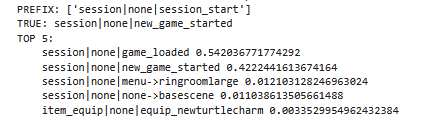

In the scenario above the first event was session_start, the model predicted that the next event would be game loaded or new game started at about a 50/50 split, which is ideal, in a normal session these are the only two options for second event.

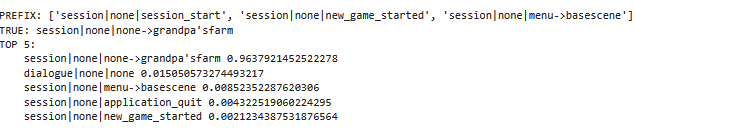

This one looks good as well, grandpa's farm is the first scene in the game and considering a new game was started this is the only option, reflected by the 96% probability that the model assigned.

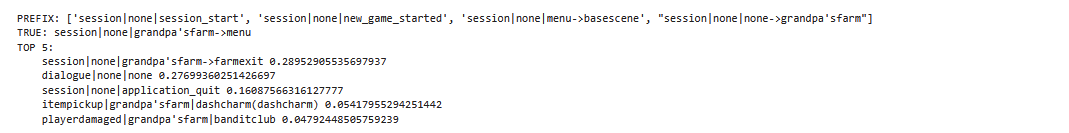

In this case the model did NOT predict the correct event, meaning this session would have received a higher anomaly score. Is this correct?

Yes. The event that occured was a return to the menu after entering the first scene, which is uncommon. Instead the model predicted that either the player would move to the next scene, or engage in dialogue with the npc in the first scene, which represent the normal gameplay flow.

This is a good sign.

Now let's take a look at some sessions in their entirety and the anomaly score which they received.

In [ ]:
top_session = session_scores.iloc[0]["session_id"]
print_session_timeline(top_session)


===== SESSION TIMELINE: c30fbb26-b688-4217-b91d-563879d1d2ea =====
Mean anomaly score: 3.839
Max anomaly score:  9.392
Num events:         34
--------------------------------------------------------------------------------
00: session|none|game_loaded                                     | score=0.462
01: session|none|none->basescene                                 | score=0.529
02: session|none|menu->grandpa'sfarm                             | score=1.780
03: session|none|grandpa'sfarm->farmexit                         | score=5.848
04: session|none|farmexit->ringroomlarge                         | score=5.379
05: itempickup|ringroomlarge|oldsword(oldsword)                  | score=5.357
06: playerdamaged|ringroomlarge|mosquito                         | score=2.242
07: playerdamaged|ringroomlarge|mosquito                         | score=1.585
08: playerdamaged|ringroomlarge|spearbandit                      | score=4.304
09: session|none|ringroomlarge->banditcampentrance               

Above is the session with the highest anomaly score, and the most anomalous event is the player being damaged by a spearbandit.

In [ ]:
print_session_timeline(session_scores.iloc[13]["session_id"])


===== SESSION TIMELINE: a4ec8602-9413-4e88-9189-fda3ece216e8 =====
Mean anomaly score: 1.976
Max anomaly score:  3.286
Num events:         12
--------------------------------------------------------------------------------
00: session|none|new_game_started                                | score=1.358
01: session|none|menu->basescene                                 | score=0.553
02: session|none|none->grandpa'sfarm                             | score=1.193
03: session|none|grandpa'sfarm->farmexit                         | score=1.821
04: itempickup|farmexit|newturtlecharm(turtlecharm)              | score=3.286
05: session|none|farmexit->ringroomlarge                         | score=1.823
06: money|none|none                                              | score=2.938
07: session|none|ringroomlarge->farmexit                         | score=2.243
08: session|none|farmexit->ringroomlarge                         | score=1.729
09: session|none|ringroomlarge->farmexit                         

Above is a short session, with an average anomaly score, the most anomalous event was the player picking up the turtlecharm.

In [ ]:
print_session_timeline(session_scores.iloc[22]["session_id"])


===== SESSION TIMELINE: f700136a-777c-4290-93f9-0ce7eb38d214 =====
Mean anomaly score: 1.217
Max anomaly score:  7.445
Num events:         28
--------------------------------------------------------------------------------
00: session|none|game_loaded                                     | score=0.462
01: session|none|none->basescene                                 | score=0.529
02: session|none|menu->grandpa'sfarm                             | score=1.780
03: playerdamaged|grandpa'sfarm|banditclub                       | score=2.916
04: playerdamaged|grandpa'sfarm|banditclub                       | score=1.017
05: playerdamaged|grandpa'sfarm|banditclub                       | score=0.491
06: playerdamaged|grandpa'sfarm|banditclub                       | score=0.315
07: playerdamaged|grandpa'sfarm|banditclub                       | score=0.247
08: playerdamaged|grandpa'sfarm|banditclub                       | score=0.209
09: playerdamaged|grandpa'sfarm|banditclub                       

This is the least anomalous run, clearly due to the fact that once the player is damaged by an enemy, it's likely it'll happen again. Interestingly enough, the most anomalous event was the player death, likely due to the fact there wasn't many deaths in the training data. Ideally after enough damage events, you'd want the model to classify them as anomalous, but this did not happen. This is quite an anomalous session considering it received the lowest score.

#**Conclusion**
---

Based on the data above, I believe this experiment to be a success. The model made a few mistakes, it classified a death as anomalous, and failed to recognize that that last sequence contained too many damage events in a row. But these mistakes are not a fault in the process, but rather due to a lack of training data. I predicted in advance that a lack of data may become a problem.

There were about 120 sessions, most of these sessions didn't go through the course of the entire game, therefore if only five out of these 120 players picked up a specific item, naturally the picking up of that item is an anomalous even. But the model could successfully identify the most common patterns within the gameplay loop (a session starts, a game is loaded, the player traverses through scenes in order, and eventually quits).

If the model were trained on ten thousand sessions rather than 80, these kinks would be ironed out, and the true anomalous events would stand out in the results.

Therefore, although this model isn't immediately useful, it fullfills its purpose as intended, and is correctly assigning higher anomaly scores to events and sessions that deviate from learned patters.